In [1]:
import sys
sys.path.append('/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages')

In [2]:
print('This is Maggie's notebook)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2448753150.py, line 1)

In [3]:
import numpy as np
import sounddevice as sd 
import lightkurve as lk
import matplotlib.pyplot as plt 

/Users/asmessier/miniconda3/envs/transitsong/lib/python3.11/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [4]:
tic = 124029677 
sector = 33

search_result = lk.search_lightcurve(
        f"TIC {tic}",
        mission="TESS",
        author="SPOC",
        sector =[sector]
    )

lc = search_result.download()


In [5]:
lc_binned = lc.bin(time_bin_size=0.01)

In [6]:
lc_fluxes = lc_binned.flux.value
lc_times = lc_binned.time.value


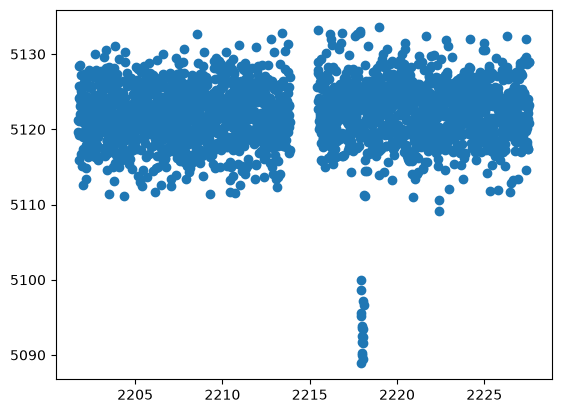

In [7]:
plt.scatter(lc_times, lc_fluxes)

In [8]:
len(lc_times)

2584

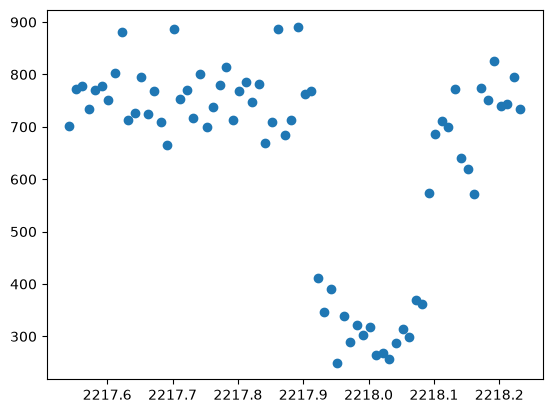

In [9]:
med_value = np.nanmedian(lc_fluxes)
lc_normflux = lc_fluxes/med_value

#central_val = 440 # hz 
max_val =900
min_val = 250

mapped_flux = (lc_normflux - np.nanmin(lc_normflux)) / (np.nanmax(lc_normflux) - np.nanmin(lc_normflux)) * (max_val - min_val) + min_val

plt.scatter(lc_times[1580:1650], mapped_flux[1580:1650])
# plt.scatter(lc_times, mapped_flux)

In [10]:
lc_normflux

MaskedNDArray([0.9998287 , 0.99951595, 0.99943596, ..., 0.9997471 ,
               1.0013133 , 1.0013198 ], shape=(2584,), dtype=float32)

In [11]:
# for a loop
freq_maps = ()

samplerate = 44100
duration = 0.05

for flux in mapped_flux[1580:1650]:
    frequency = flux 
    t = np.linspace(0, duration, int(samplerate * duration), endpoint=False)
    
    audio_signal = 0.5 * np.sin(2*np.pi*frequency*t)

    sd.play(audio_signal, samplerate)
    sd.wait()


In [12]:
from scipy.io.wavfile import write

In [13]:
samplerate = 44100
duration = 0.05

audio = []

for flux in mapped_flux[1580:1650]:
    frequency = flux 
    t = np.linspace(0, duration, int(samplerate * duration), endpoint=False)
    
    audio_signal = np.sin(2*np.pi*frequency*t)
    
    audio.extend(audio_signal)

arr = np.array(audio)
    

In [14]:
sd.play(arr, samplerate)
sd.wait()

In [15]:
import matplotlib.animation as animation

In [16]:
plt.scatter(x,y)

NameError: name 'x' is not defined

In [17]:
len(x)

NameError: name 'x' is not defined

MovieWriter ffmpeg unavailable; using Pillow instead.


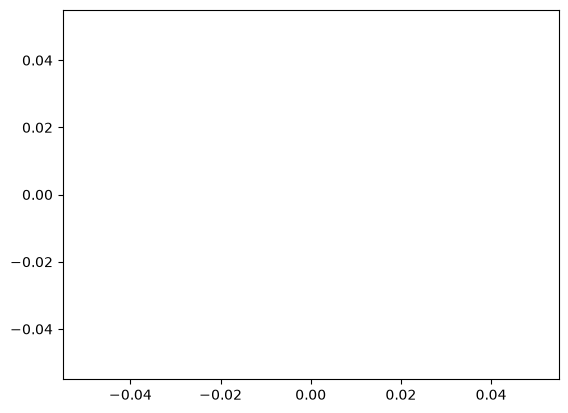

In [26]:
fig = plt.figure()
x = lc_times[1580:1650]
y = mapped_flux[1580:1650]

graph, = plt.plot([], [], 'o')

def animate(i):
    graph.set_data(x[:i+1], y[:i+1])
    return graph


# def animate(i):
#     scat.set_offsets((lc_times[1580:1650]))
#     return (scat,)

ani = animation.FuncAnimation(fig, animate, frames=len(x))
ani.save(filename="plots/ffmpeg_example.gif", writer="ffmpeg")
#plt.show()



/var/folders/40/kbbyct317p774wpv84k12390000647/T/ipykernel_98229/146364413.py:22: UserWarning: frames=None which we can infer the length of, did not pass an explicit *save_count* and passed cache_frame_data=True.  To avoid a possibly unbounded cache, frame data caching has been disabled. To suppress this warning either pass `cache_frame_data=False` or `save_count=MAX_FRAMES`.
  ani = FuncAnimation(fig, animate, repeat=False, interval=200)
/Users/asmessier/miniconda3/envs/transitsong/lib/python3.11/site-packages/matplotlib/animation.py:916: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


FileNotFoundError: [Errno 2] No such file or directory: 'ffmpeg'

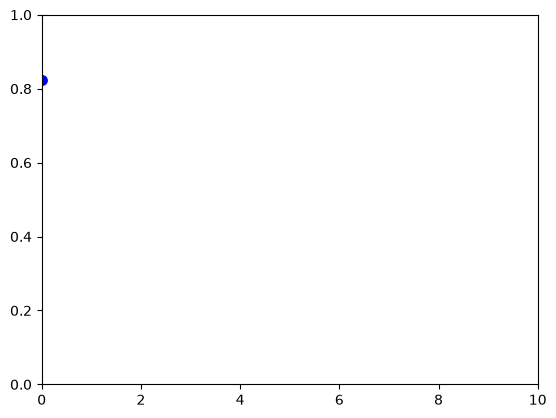

In [ ]:
# Copy
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

x = np.arange(10)
y = np.random.random(10)
size = np.random.randint(150, size=10)
colors = np.random.choice(["r", "g", "b"], size=10)

fig = plt.figure()
plt.xlim(0, 10)
plt.ylim(0, 1)
graph = plt.scatter([], [])

def animate(i):
    graph.set_offsets(np.vstack((x[:i+1], y[:i+1])).T)
    graph.set_sizes(size[:i+1])
    graph.set_facecolors(colors[:i+1])
    return graph

ani = FuncAnimation(fig, animate, repeat=False, interval=200)


MovieWriter ffmpeg unavailable; using Pillow instead.


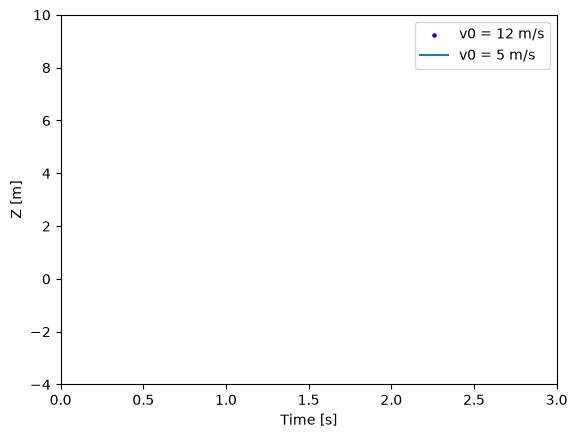

In [29]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.animation as animation

fig, ax = plt.subplots()
t = np.linspace(0, 3, 40)
g = -9.81
v0 = 12
z = g * t**2 / 2 + v0 * t

v02 = 5
z2 = g * t**2 / 2 + v02 * t

scat = ax.scatter(t[0], z[0], c="b", s=5, label=f'v0 = {v0} m/s')
line2 = ax.plot(t[0], z2[0], label=f'v0 = {v02} m/s')[0]
ax.set(xlim=(0, 3), ylim=(-4, 10), xlabel='Time [s]', ylabel='Z [m]')
ax.legend()


def update(frame):
    # for each frame, update the data stored on each artist.
    x = t[:frame]
    y = z[:frame]
    # update the scatter plot:
    data = np.stack([x, y]).T
    scat.set_offsets(data)
    # update the line plot:
    line2.set_xdata(t[:frame])
    line2.set_ydata(z2[:frame])
    return (scat, line2)


ani = animation.FuncAnimation(fig=fig, func=update, frames=40, interval=30)
ani.save(filename="plots/ffmpeg_example.gif", writer="ffmpeg")